#1.Install packages, imports, seeds, and parameters

In [ ]:
import os

os.environ["TRANSFORMERS_NO_TORCH"] = "1"
os.environ["USE_TORCH"] = "0"
os.environ["USE_TF"] = "1"

print("Environment flags set successfully")


Environment flags set successfully


In [ ]:
!pip install -q tensorflow==2.16.2 tf-keras transformers==4.41.2
!pip install -q scikit-learn matplotlib seaborn nlpaug joblib onnx onnxruntime


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.8/590.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 66.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sourc

***Restart Runtime (Mandatory)***

In [ ]:
from transformers import AutoTokenizer
from transformers.models.auto.modeling_tf_auto import TFAutoModel

import tensorflow as tf
import numpy as np
import pandas as pd

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TFAutoModel loaded OK")


TensorFlow: 2.16.2
NumPy: 1.26.4
Pandas: 2.2.2
TFAutoModel loaded OK


In [ ]:
from transformers import AutoTokenizer
from transformers.models.auto.modeling_tf_auto import TFAutoModel

import os, random, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


In [ ]:
print("Python OK")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("TF:", tf.__version__)
print("TFAutoModel loaded:", TFAutoModel)


Python OK
NumPy: 1.26.4
Pandas: 2.2.2
TF: 2.16.2
TFAutoModel loaded: <class 'transformers.models.auto.modeling_tf_auto.TFAutoModel'>


In [ ]:
# Parameters
DATA_PATH = "mental_health.csv"   # upload this file to Colab
MODEL_NAME = "prajjwal1/bert-tiny"  # student base
MAX_LEN = 96
SVD_DIMS = 256
ADAPTER_BOTTLENECK = 64
#ADAPTER_BOTTLENECK = 96
HEAD_DIM = 384
#HEAD_DIM = 512
BATCH_SIZE = 8
EPOCHS = 20
LR = 2e-5
#LR = 1e-5
WARMUP_PCT = 0.06
USE_AUGMENT = True
AUG_PCT = 0.08
LABEL_SMOOTH = 0.05
#LABEL_SMOOTH = 0.02
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("Environment ready. TF version:", tf.__version__, "GPU available:", bool(tf.config.list_physical_devices('GPU')))

Environment ready. TF version: 2.16.2 GPU available: False


#2. Loading Mental Health Dataset Corpus

In [ ]:
# 2. Dataset loading
DATA_PATH = "mental_health.csv"
assert os.path.exists(DATA_PATH), "Upload mental_health.csv to Colab session storage."

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print(df.head())
# Expect columns 'text' and 'label'

Dataset shape: (27977, 2)
                                                text  label
0  dear american teens question dutch person hear...      0
1  nothing look forward lifei dont many reasons k...      1
2  music recommendations im looking expand playli...      0
3  im done trying feel betterthe reason im still ...      1
4  worried  year old girl subject domestic physic...      1


#3. EDA

label
0    14139
1    13838
Name: count, dtype: int64


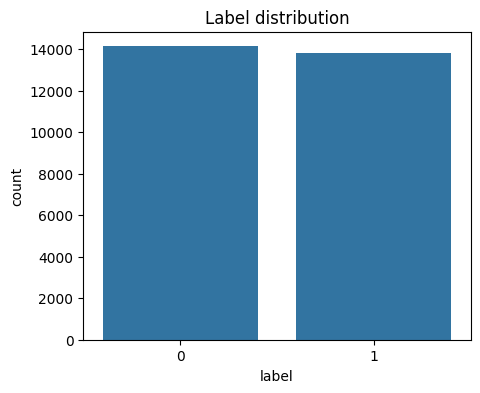

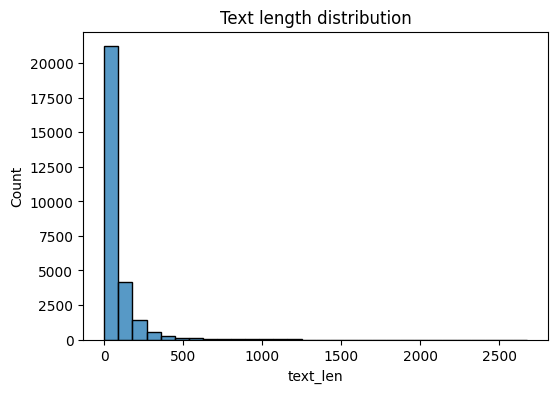

In [ ]:
# 3. Exploratory Data Analysis
print(df['label'].value_counts())
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df)
plt.title("Label distribution")
plt.show()

df['text_len'] = df['text'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(6,4))
sns.histplot(df['text_len'], bins=30)
plt.title("Text length distribution")
plt.show()

#4. NLP Data Preprocessing

In [ ]:
# --- BEGIN: advanced preprocessing for mental_health.csv (paste into your main program) ---
import re, string, unicodedata, html, pandas as pd

# optional packages — graceful fallbacks
try:
    import ftfy
except Exception:
    ftfy = None
try:
    import contractions
except Exception:
    contractions = None
try:
    import emoji
except Exception:
    emoji = None

# spaCy lemmatizer (preferred)
USE_SPACY = True
try:
    import spacy
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
except Exception:
    USE_SPACY = False
    nlp = None

# small helper utilities
_SIMPLE_CONTRACTIONS = {"ain't":"is not","aren't":"are not","can't":"cannot","won't":"will not",
                       "i'm":"i am","i've":"i have","i'd":"i would","i'll":"i will",
                       "don't":"do not","didn't":"did not","doesn't":"do not","you're":"you are"}

def _expand_contractions(text):
    if contractions:
        return contractions.fix(text)
    pattern = re.compile(r'\b(' + '|'.join(re.escape(k) for k in _SIMPLE_CONTRACTIONS) + r')\b')
    return pattern.sub(lambda m: _SIMPLE_CONTRACTIONS[m.group(0)], text)

def _remove_emojis(text):
    if emoji:
        return emoji.replace_emoji(text, replace='')
    return re.sub(r'['
                  u'\U0001F300-\U0001F6FF'
                  u'\U0001F900-\U0001F9FF'
                  u'\U0001F1E0-\U0001F1FF'
                  u'\u2600-\u26FF\u2700-\u27BF]+', '', text)

_repeated_re = re.compile(r'(.)\1{2,}', re.DOTALL)
def _reduce_lengthening(w):
    return _repeated_re.sub(r'\1\1', w)

def advanced_clean_text(text,
                        expand_contractions_flag=True,
                        remove_emojis_flag=True,
                        ascii_only=True,
                        keep_numbers=False):
    if pd.isna(text): return ""
    s = str(text)

    # HTML & entities
    s = html.unescape(s)
    s = re.sub(r'<[^>]+>', ' ', s)

    # fix encoding quirks
    if ftfy:
        try: s = ftfy.fix_text(s)
        except: pass

    s = s.lower()

    if expand_contractions_flag:
        s = _expand_contractions(s)

    # remove urls, emails, phone-like patterns, mentions/hashtags
    s = re.sub(r'http\S+|www\.\S+|https\S+', ' ', s)
    s = re.sub(r'\S+@\S+', ' ', s)
    s = re.sub(r'\+?\d[\d\-\s]{7,}\d', ' ', s)
    s = re.sub(r'@\w+|#\w+', ' ', s)

    # emojis
    if remove_emojis_flag:
        s = _remove_emojis(s)

    # normalize unicode and optionally keep ascii only
    s = unicodedata.normalize('NFKC', s)
    if ascii_only:
        s = s.encode('ascii', errors='ignore').decode('ascii')

    # remove punctuation -> spaces (keeps boundaries)
    s = s.translate(str.maketrans(string.punctuation, ' '*len(string.punctuation)))
    s = re.sub(r'\s+', ' ', s).strip()

    # reduce elongated characters
    s = ' '.join(_reduce_lengthening(w) for w in s.split())

    # optionally drop standalone numbers
    if not keep_numbers:
        s = re.sub(r'\b\d+\b', ' ', s)
        s = re.sub(r'\s+', ' ', s).strip()

    return s

# --- Apply to DataFrame with spaCy lemmatization in batch (fast) ---
def preprocess_mental_health(csv_path="/mnt/data/mental_health.csv",
                             text_col="text", label_col="label",
                             remove_emojis_flag=True, ascii_only=True):
    df = pd.read_csv(csv_path)

    # 1) basic advanced cleaning (fast, CPU-light)
    df['text_clean_prelemm'] = df[text_col].apply(
        lambda t: advanced_clean_text(t,
                                      expand_contractions_flag=True,
                                      remove_emojis_flag=remove_emojis_flag,
                                      ascii_only=ascii_only,
                                      keep_numbers=False)
    )

    # 2) lemmatize using spaCy if available (use nlp.pipe for speed), otherwise keep pre-lemmatized text
    if USE_SPACY and nlp is not None:
        texts = df['text_clean_prelemm'].fillna("").astype(str).tolist()
        lemmas = []
        for doc in nlp.pipe(texts, batch_size=200):
            # keep tokens that are alpha or have sentiment value; drop punctuation & spaces
            tokens = [tok.lemma_ for tok in doc if not tok.is_space and not tok.is_punct]
            lemmas.append(" ".join(tokens))
        df['text_clean'] = lemmas
    else:
        df['text_clean'] = df['text_clean_prelemm']

    # 3) final normalization: collapse whitespace
    df['text_clean'] = df['text_clean'].str.replace(r'\s+', ' ', regex=True).str.strip()

    # 4) binary label mapping (keeps original ordering of label values)
    if df[label_col].dtype == object:
        uniques = list(df[label_col].dropna().unique())
        if len(uniques) != 2:
            raise ValueError("Expect binary labels. Found: " + str(uniques))
        label_map = {uniques[0]: 0, uniques[1]: 1}
        df['label_id'] = df[label_col].map(label_map)
    else:
        df['label_id'] = df[label_col].astype(int)

    # drop helper column
    df = df.drop(columns=['text_clean_prelemm'])
    return df

# Example usage:
df = preprocess_mental_health(csv_path="mental_health.csv", text_col="text", label_col="label",
                              remove_emojis_flag=False, ascii_only=True)
print(df[['text','text_clean','label','label_id']].head())

                                                text  \
0  dear american teens question dutch person hear...   
1  nothing look forward lifei dont many reasons k...   
2  music recommendations im looking expand playli...   
3  im done trying feel betterthe reason im still ...   
4  worried  year old girl subject domestic physic...   

                                          text_clean  label  label_id  
0  dear american teen question dutch person hear ...      0         0  
1  nothing look forward lifei do not many reason ...      1         1  
2  music recommendation I m look expand playlist ...      0         0  
3  I m do try feel betterthe reason I m still ali...      1         1  
4  worry year old girl subject domestic physicalm...      1         1  


#5.TF-IDF + SVD lexical features (SVD_DIMS)

In [ ]:
# Cell 3 - Lexical features: TF-IDF -> TruncatedSVD
print("Building TF-IDF and SVD features (SVD_DIMS=%d)..." % SVD_DIMS)
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=12000, min_df=2)
X_tfidf = tfidf.fit_transform(df['text_clean'].tolist())
svd = TruncatedSVD(n_components=SVD_DIMS, random_state=RANDOM_SEED)
X_lex = svd.fit_transform(X_tfidf)
print("Lexical shape:", X_lex.shape)

# save artifacts for deployment
joblib.dump(tfidf, os.path.join(ARTIFACT_DIR, "tfidf.joblib"))
joblib.dump(svd, os.path.join(ARTIFACT_DIR, "svd.joblib"))


Building TF-IDF and SVD features (SVD_DIMS=256)...
Lexical shape: (27977, 256)


['artifacts/svd.joblib']

#6.Train-test split and optional augmentation

In [ ]:
# Cell 4 - Train-test split and light augmentation
test_size = 0.20
X_texts = df['text_clean'].tolist()
y = df['label_id'].astype(int).tolist()

X_train_texts, X_test_texts, y_train, y_test, idx_train, idx_test = train_test_split(
    X_texts, y, list(range(len(X_texts))), test_size=test_size, stratify=y, random_state=RANDOM_SEED, shuffle=True)

# Lex vectors for splits (aligned by original index)
X_train_lex = X_lex[idx_train]
X_test_lex  = X_lex[idx_test]

print("Train/test sizes:", len(X_train_texts), len(X_test_texts))
print("Train label distribution:", Counter(y_train))

# Optional light augmentation (synonym replacement) - inexpensive
if USE_AUGMENT:
    print("Applying light synonym augmentation (AUG_PCT=%0.2f)..." % AUG_PCT)
    try:
        import nlpaug.augmenter.word as naw
        aug = naw.SynonymAug(aug_src='wordnet', aug_p=AUG_PCT)
        aug_texts, aug_labels, aug_lex = [], [], []
        for txt, lbl, lex in zip(X_train_texts, y_train, X_train_lex):
            try:
                newtxt = aug.augment(txt)
                if newtxt and newtxt != txt:
                    aug_texts.append(newtxt)
                    aug_labels.append(lbl)
                    new_tfidf = tfidf.transform([newtxt])
                    new_svd = svd.transform(new_tfidf)
                    aug_lex.append(new_svd[0])
            except Exception:
                continue
        if len(aug_texts) > 0:
            X_train_texts = X_train_texts + aug_texts
            y_train = y_train + aug_labels
            X_train_lex = np.vstack([X_train_lex, np.array(aug_lex)])
            print("After augmentation train size:", len(X_train_texts))
        else:
            print("No augmented texts generated.")
    except Exception as e:
        print("Augment failed:", e)
else:
    print("Augmentation disabled.")


Train/test sizes: 22381 5596
Train label distribution: Counter({0: 11311, 1: 11070})
Applying light synonym augmentation (AUG_PCT=0.08)...


Streaming output truncated to the last 5000 lines.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_dat

No augmented texts generated.


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger t

#7.Tokenize train & test with Hugging Face tokenizer

In [ ]:
# Cell 5 - Tokenize with AutoTokenizer
print("Loading tokenizer:", MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_enc = tokenizer(X_train_texts, truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='np')
test_enc  = tokenizer(X_test_texts, truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='np')

print("Tokenized shapes:", train_enc['input_ids'].shape, test_enc['input_ids'].shape)


Loading tokenizer: prajjwal1/bert-tiny


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenized shapes: (22381, 96) (5596, 96)


#8. Build TinyBERT student model (Lambda wrapper, Adapter, Lexical fusion)

In [ ]:
print("Loading TinyBERT base (may convert PyTorch->TF if needed)...")
try:
    base_student = TFAutoModel.from_pretrained(MODEL_NAME)
except Exception:
    base_student = TFAutoModel.from_pretrained(MODEL_NAME, from_pt=True)

# Custom Layer to wrap the base_student model for proper variable tracking
class BertBaseLayer(tf.keras.layers.Layer):
    def __init__(self, base_model, **kwargs):
        super().__init__(**kwargs)
        self.base_model = base_model

    def call(self, inputs):
        ids, mask = inputs
        out = self.base_model(input_ids=ids, attention_mask=mask, training=True)
        return out.last_hidden_state

# Adapter layer
class Adapter(tf.keras.layers.Layer):
    def __init__(self, dim, bottleneck=ADAPTER_BOTTLENECK, **kwargs):
        super().__init__(**kwargs)
        self.down = tf.keras.layers.Dense(bottleneck, activation='relu')
        self.up = tf.keras.layers.Dense(dim)
    def call(self, x):
        return x + self.up(self.down(x))

hidden_size = getattr(base_student.config, "hidden_size", 128)
lex_dim = SVD_DIMS

# Inputs
input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")
lex_input = tf.keras.Input(shape=(lex_dim,), dtype=tf.float32, name="lex_input")

# Use the custom layer instead of Lambda to correctly track base_student variables
bert_base_layer = BertBaseLayer(base_student, name="hf_bert_wrapper")
bert_last = bert_base_layer([input_ids, attention_mask])

cls_token = tf.keras.layers.Lambda(lambda x: x[:,0,:], output_shape=(hidden_size,), name="cls_token")(bert_last)

x = tf.keras.layers.Dropout(0.1)(cls_token)
x = Adapter(dim=hidden_size, bottleneck=ADAPTER_BOTTLENECK)(x)
x = tf.keras.layers.Concatenate()([x, lex_input])
x = tf.keras.layers.Dense(HEAD_DIM, activation='relu')(x)
x = tf.keras.layers.Dropout(0.15)(x)
logit = tf.keras.layers.Dense(1, name="logit")(x)  # single logit (from_logits)

student = tf.keras.Model(inputs=[input_ids, attention_mask, lex_input], outputs=logit)
print("Student params:", student.count_params())
student.summary()

Loading TinyBERT base (may convert PyTorch->TF if needed)...


pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'bert.embeddings.position_ids', 'cls.predictions.decoder.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the 

Student params: 4550721
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 96)]                 0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 96)]                 0         []                            
 )                                                                                                
                                                                                                  
 hf_bert_wrapper (BertBaseL  (None, 96, 128)              4385920   ['input_ids[0][0]',           
 ayer)                                                               'attention_mask[0][0]']      
                                                                      

#9. Unfreeze base, loss, Keras warmup schedule & optimizer

In [ ]:
# Cell 7 - Unfreeze base, define loss (label-smoothed BCE), LR schedule and optimizer
# Full fine-tune
base_student.trainable = True
print("Base model trainable:", base_student.trainable)

# Loss: label smoothed BCE
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True, label_smoothing=LABEL_SMOOTH)

# Keras-compatible warmup + linear decay schedule
class WarmupLinearDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, init_lr, num_train_steps, warmup_steps):
        super().__init__()
        self.init_lr = init_lr
        self.num_train_steps = tf.cast(num_train_steps, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.init_lr * (step / tf.maximum(1.0, self.warmup_steps))
        decay_steps = tf.maximum(1.0, self.num_train_steps - self.warmup_steps)
        decay_percent = (step - self.warmup_steps) / decay_steps
        decay_percent = tf.clip_by_value(decay_percent, 0.0, 1.0)
        decay_lr = self.init_lr * (1.0 - decay_percent)
        lr = tf.where(step < self.warmup_steps, warmup_lr, decay_lr)
        return lr
    def get_config(self):
        return {"init_lr": float(self.init_lr), "num_train_steps": float(self.num_train_steps), "warmup_steps": float(self.warmup_steps)}

num_train_steps = int(np.ceil(len(y_train) / BATCH_SIZE) * EPOCHS)
warmup_steps = int(WARMUP_PCT * num_train_steps)
lr_schedule = WarmupLinearDecay(LR, num_train_steps, warmup_steps)
opt = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# compile
student.compile(optimizer=opt, loss=loss_fn, metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"), tf.keras.metrics.AUC(name="auc")])
print("Model compiled.")


Base model trainable: True
Model compiled.


#10.Prepare numpy inputs, class weights, callbacks and train

In [ ]:
# Cell 8 - Prepare inputs, compute class weights, callbacks, and train
train_inputs = {
    "input_ids": train_enc['input_ids'],
    "attention_mask": train_enc['attention_mask'],
    "lex_input": X_train_lex.astype(np.float32)
}
val_inputs = {
    "input_ids": test_enc['input_ids'],
    "attention_mask": test_enc['attention_mask'],
    "lex_input": X_test_lex.astype(np.float32)
}
y_train_np = np.array(y_train, dtype=np.float32)
y_test_np  = np.array(y_test, dtype=np.float32)

# balanced class weights
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_np), y=y_train_np)
class_weight_dict = {int(k): float(v) for k,v in zip(np.unique(y_train_np), cw)}
print("Class weights:", class_weight_dict)

# Callbacks
ckpt = os.path.join(ARTIFACT_DIR, "best_student.weights.h5")
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
mc = tf.keras.callbacks.ModelCheckpoint(ckpt, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1)

# Train
history = student.fit(train_inputs, y_train_np,
                      validation_data=(val_inputs, y_test_np),
                      epochs=EPOCHS,
                      batch_size=BATCH_SIZE,
                      class_weight=class_weight_dict,
                      callbacks=[es, mc],
                      verbose=1)

# load best weights if saved
if os.path.exists(ckpt):
    student.load_weights(ckpt)
    print("Loaded best checkpoint weights.")


Class weights: {0: 0.9893466536999381, 1: 1.0108852755194218}
Epoch 1/20


2798/2798 [==============================] - ETA: 0s - loss: 0.4715 - accuracy: 0.7795 - auc: 0.8354
Epoch 1: val_loss improved from inf to 0.33087, saving model to artifacts/best_student.weights.h5


/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


2798/2798 [==============================] - 370s 124ms/step - loss: 0.4715 - accuracy: 0.7795 - auc: 0.8354 - val_loss: 0.3309 - val_accuracy: 0.8871 - val_auc: 0.9133
Epoch 2/20
2798/2798 [==============================] - ETA: 0s - loss: 0.2881 - accuracy: 0.9099 - auc: 0.9308
Epoch 2: val_loss improved from 0.33087 to 0.27182, saving model to artifacts/best_student.weights.h5
2798/2798 [==============================] - 338s 121ms/step - loss: 0.2881 - accuracy: 0.9099 - auc: 0.9308 - val_loss: 0.2718 - val_accuracy: 0.9153 - val_auc: 0.9335
Epoch 3/20
2798/2798 [==============================] - ETA: 0s - loss: 0.2502 - accuracy: 0.9300 - auc: 0.9462
Epoch 3: val_loss did not improve from 0.27182
2798/2798 [==============================] - 338s 121ms/step - loss: 0.2502 - accuracy: 0.9300 - auc: 0.9462 - val_loss: 0.2737 - val_accuracy: 0.9228 - val_auc: 0.9412
Epoch 4/20
2798/2798 [==============================] - ETA: 0s - loss: 0.2288 - accuracy: 0.9423 - auc: 0.9555
Epoch 4:

In [ ]:
# Save the trained student model
STUDENT_DIR = "stress_student_savedmodel"
student.save(STUDENT_DIR)

print("Saved Keras model to:", STUDENT_DIR)


Saved Keras model to: stress_student_savedmodel


In [ ]:
from google.colab import files
files.download("stress_student_savedmodel")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved training metrics plot training_metrics.png


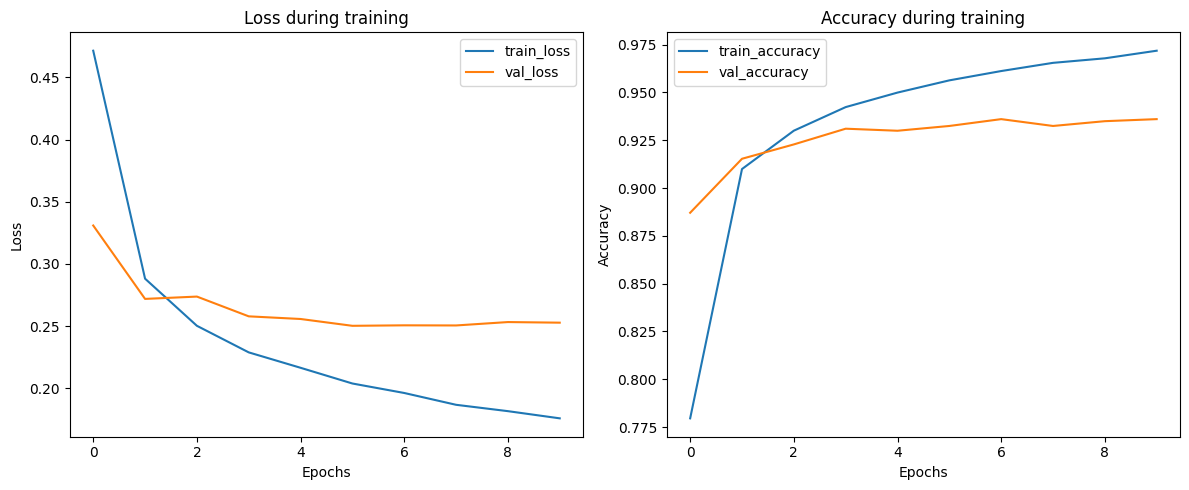

In [ ]:
# Save training history plot (loss & metrics)
plt.figure(figsize=(12, 5))

# Subplot 1: Loss vs. Epochs
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history.get('loss', []), label='train_loss')
plt.plot(history.history.get('val_loss', []), label='val_loss')
plt.legend()
plt.title("Loss during training")
plt.xlabel("Epochs")
plt.ylabel("Loss")

# Subplot 2: Accuracy vs. Epochs
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history.get('accuracy', []), label='train_accuracy')
plt.plot(history.history.get('val_accuracy', []), label='val_accuracy')
plt.legend()
plt.title("Accuracy during training")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.savefig("training_metrics.png", dpi=150)
print("Saved training metrics plot training_metrics.png")

In [ ]:
print("input_ids shape:", train_enc["input_ids"].shape)
print("attention_mask shape:", train_enc["attention_mask"].shape)
print("lexical features shape:", X_train_lex.shape)

input_ids shape: (22381, 96)
attention_mask shape: (22381, 96)
lexical features shape: (22381, 256)


**Representative dataset generator (MANDATORY for INT8)**

In [ ]:
import numpy as np

def representative_data_gen():
    for i in range(100):
        yield {
            "input_ids": np.asarray(train_enc["input_ids"][i:i+1], dtype=np.int32),
            "attention_mask": np.asarray(train_enc["attention_mask"][i:i+1], dtype=np.int32),
            "lex_input": np.asarray(X_train_svd[i:i+1], dtype=np.float32)
        }



**INT8 TFLite conversion**

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_saved_model(STUDENT_DIR)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.TFLITE_BUILTINS
]


In [ ]:
# Rebuild TF-IDF + SVD (must match training)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

tfidf = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(X_train_texts)   # SAME texts used in training

svd = TruncatedSVD(
    n_components=SVD_DIMS,
    random_state=42
)

X_train_svd = svd.fit_transform(X_tfidf)

print("X_train_svd shape:", X_train_svd.shape)


X_train_svd shape: (22381, 256)


**TFLite INT8 Model**

In [ ]:
tflite_model_int8 = converter.convert()

with open("stress_student_int8.tflite", "wb") as f:
    f.write(tflite_model_int8)

print("✅ INT8 TFLite conversion successful")
print("Model size (MB):", len(tflite_model_int8) / (1024 * 1024))


✅ INT8 TFLite conversion successful
Model size (MB): 4.341758728027344


In [ ]:
from google.colab import files
files.download("stress_student_int8.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**TFLite FP16**

In [ ]:
import tensorflow as tf

# Create TFLite converter from SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model(STUDENT_DIR)

# Enable optimization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 🔥 KEY CHANGE: enable FP16 quantization
converter.target_spec.supported_types = [tf.float16]

# Convert to FP16 TFLite
tflite_model_fp16 = converter.convert()

# Save FP16 model
with open("stress_student_fp16.tflite", "wb") as f:
    f.write(tflite_model_fp16)

print("✅ FP16 TFLite conversion successful")
print("Model size (MB):", len(tflite_model_fp16) / (1024 * 1024))


✅ FP16 TFLite conversion successful
Model size (MB): 8.609855651855469


In [ ]:
from google.colab import files
files.download("stress_student_fp16.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#11.  Predictions on test set (logits -> sigmoid -> probabilities)

In [ ]:
import numpy as np
logits = student.predict(val_inputs, batch_size=BATCH_SIZE).reshape(-1)
probs = 1/(1+np.exp(-logits))
preds = (probs >= 0.5).astype(int)

print("Classification report (validation):")
print(classification_report(y_test_np, preds, target_names=['no_stress','stress']))

700/700 [==============================] - 34s 45ms/step
Classification report (validation):
              precision    recall  f1-score   support

   no_stress       0.94      0.92      0.93      2828
      stress       0.92      0.94      0.93      2768

    accuracy                           0.93      5596
   macro avg       0.93      0.93      0.93      5596
weighted avg       0.93      0.93      0.93      5596



#12. Confusion Matrix and Classification Report (Test)

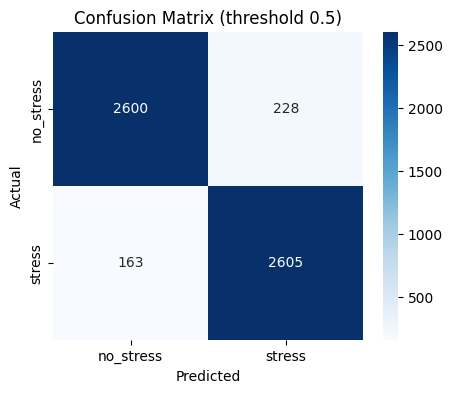

Classification Report (threshold 0.5):

              precision    recall  f1-score   support

   no_stress       0.94      0.92      0.93      2828
      stress       0.92      0.94      0.93      2768

    accuracy                           0.93      5596
   macro avg       0.93      0.93      0.93      5596
weighted avg       0.93      0.93      0.93      5596



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test_np, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no_stress","stress"], yticklabels=["no_stress","stress"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (threshold 0.5)")
plt.show()

print("Classification Report (threshold 0.5):\n")
print(classification_report(y_test_np, preds, target_names=["no_stress","stress"]))

#13. ROC and PR Curves

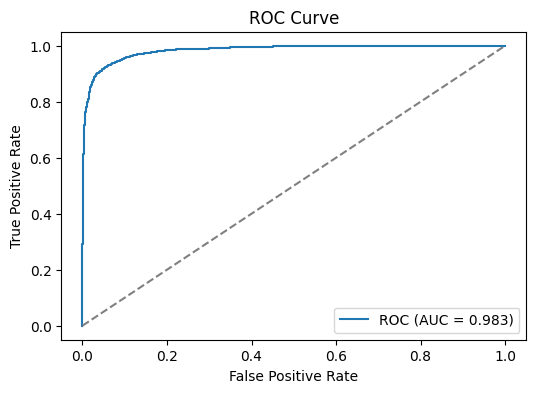

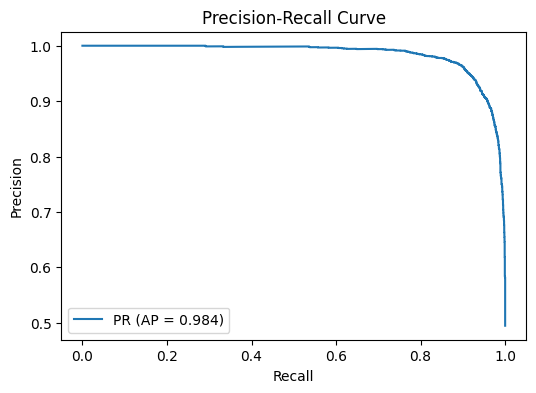

ROC-AUC: 0.9835, Average Precision (AP): 0.9841


In [ ]:
# ===== Cell 15: ROC & PR curves =====
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fpr, tpr, _ = roc_curve(y_test_np, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

precision, recall, _ = precision_recall_curve(y_test_np, probs)
ap = average_precision_score(y_test_np, probs)

plt.figure(figsize=(6,4))
plt.plot(recall, precision, label=f"PR (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}, Average Precision (AP): {ap:.4f}")

#14. Agent / Response Module (predefined suggestions + severity decision)

In [ ]:
# Cell 12 - Agent / Response Module (offline, deterministic)
# Input: single-line text (or short paragraph)
# Output: severity label + predefined suggestion string

# Severity thresholds (tunable)
THRESHOLD_HIGH = 0.70
THRESHOLD_LOW  = 0.45

def preprocess_for_agent(text):
    # same cleaning & tokenization + lex transform
    t = advanced_clean_text(text)
    enc = tokenizer([t], truncation=True, padding='max_length', max_length=MAX_LEN, return_tensors='np')
    lex_v = svd.transform(tfidf.transform([t]))  # shape (1, SVD_DIMS)
    inputs = {"input_ids": enc['input_ids'], "attention_mask": enc['attention_mask'], "lex_input": lex_v.astype(np.float32)}
    return inputs

def severity_from_prob(p, low=THRESHOLD_LOW, high=THRESHOLD_HIGH):
    if p >= high:
        return "HIGH"
    if p >= low:
        return "MODERATE"
    return "NO_STRESS"

# Predefined suggestions (example; edit to match your safety policy / local resources)
SUGGESTIONS = {
    "NO_STRESS": "No stress detected. Short tips: take regular breaks, get fresh air, stay hydrated.",
    "MODERATE": "Moderate stress detected. Try: 2-minute breathing exercise, short walk, talk to a friend. If you feel worse, consider reaching out to a professional.",
    "HIGH": "High stress detected — please pause and consider immediate help. If you are in danger or having thoughts of harming yourself, contact local emergency services or a crisis hotline immediately."
}

def agent_response(text):
    inputs = preprocess_for_agent(text)
    logit = student.predict(inputs).reshape(-1)[0]
    prob = 1/(1+math.exp(-float(logit)))
    severity = severity_from_prob(prob)
    msg = SUGGESTIONS[severity]
    # optionally include follow-up clarifying Qs for MODERATE/HIGH
    followup = ""
    if severity == "HIGH":
        followup = " Are you currently safe? If not, please call your local emergency number or a crisis hotline now."
    elif severity == "MODERATE":
        followup = " Would you like a 2-minute breathing audio guide? (Y/N)"
    return {"probability": prob, "severity": severity, "message": msg + followup}




In [ ]:
# Example usage:
examples = [
    "I feel overwhelmed and cannot sleep for days.",
    "I am so happy with my new job!",
    "Sometimes I think about harming myself and it scares me.",
    "I thought to suicide and also kill somebody"
]
for ex in examples:
    out = agent_response(ex)
    print("Text:", ex)
    print("Severity:", out['severity'], "Prob:", f"{out['probability']:.3f}")
    print("Agent message:", out['message'])
    print("---")

1/1 [==============================] - 0s 27ms/step
Text: I feel overwhelmed and cannot sleep for days.
Severity: HIGH Prob: 0.843
Agent message: High stress detected — please pause and consider immediate help. If you are in danger or having thoughts of harming yourself, contact local emergency services or a crisis hotline immediately. Are you currently safe? If not, please call your local emergency number or a crisis hotline now.
---
1/1 [==============================] - 0s 23ms/step
Text: I am so happy with my new job!
Severity: NO_STRESS Prob: 0.361
Agent message: No stress detected. Short tips: take regular breaks, get fresh air, stay hydrated.
---
1/1 [==============================] - 0s 30ms/step
Text: Sometimes I think about harming myself and it scares me.
Severity: HIGH Prob: 0.876
Agent message: High stress detected — please pause and consider immediate help. If you are in danger or having thoughts of harming yourself, contact local emergency services or a crisis hotline im

#15.Save artifacts (final weights, tokenizer) and helper exports

In [ ]:
# Cell 11 - Save artifacts for deployment
# save model weights (for later TFLite conversion), tokenizer, and lex tools
#student.save_weights(os.path.join(ARTIFACT_DIR, "student_final.weights.h5"))
tokenizer.save_pretrained(os.path.join(ARTIFACT_DIR, "tokenizer"))
joblib.dump(tfidf, os.path.join(ARTIFACT_DIR, "tfidf.joblib"))
joblib.dump(svd, os.path.join(ARTIFACT_DIR, "svd.joblib"))
print("Saved artifacts in", ARTIFACT_DIR)


Saved artifacts in artifacts


In [ ]:
import shutil
import os
from google.colab import files

# Define the path to the tokenizer directory
tokenizer_dir = os.path.join(ARTIFACT_DIR, "tokenizer")
zip_filename = "tokenizer.zip"

# Create a zip archive of the tokenizer directory
shutil.make_archive("tokenizer", 'zip', tokenizer_dir)

# Download the zip file
files.download(zip_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import os

files.download(os.path.join(ARTIFACT_DIR, "tfidf.joblib"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import os

files.download(os.path.join(ARTIFACT_DIR, "svd.joblib"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>